In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LinearSegmentedColormap

# --- Colormap ---
red_black = LinearSegmentedColormap.from_list("red_black", ["black", "red"])

# --- Parameters ---
lam = 532e-9
alpha = 1.2e11
xmax = 2.5e-5

# --- Grid ---
N = 400
x = np.linspace(-xmax, xmax, N)
y = np.linspace(-xmax, xmax, N)
X, Y = np.meshgrid(x, y)
R2 = X**2 + Y**2

# --- Detector position ---
x0, y0 = 0, 0
ix = np.argmin(np.abs(x - x0))
iy = np.argmin(np.abs(y - y0))

# --- ΔL values ---
dL_vals = np.linspace(0, 2 * lam, 120)

I_hist = np.zeros(len(dL_vals))

# --- Figure ---
fig, (ax2d, ax1d) = plt.subplots(
    1, 2, figsize=(10, 5),
    gridspec_kw={"width_ratios": [1.2, 1]}
)

plt.tight_layout()

# --- Initial image ---
I0 = 0.5 * (1 + np.cos(alpha * R2))
im = ax2d.imshow(
    I0,
    extent=[x.min()*1e3, x.max()*1e3, y.min()*1e3, y.max()*1e3],
    origin='lower',
    cmap=red_black
)

# Detector marker
ax2d.scatter(x0*1e3, y0*1e3, color="white", s=50, edgecolor="black")

# Line plot
line, = ax1d.plot([], [], color="crimson", lw=2)

# --- Update function ---
def update(frame):
    dL = dL_vals[frame]

    phi = alpha * R2 + (4*np.pi/lam)*dL
    I = 0.5 * (1 + np.cos(phi))

    im.set_data(I)

    # Detector signal
    I_det = I[iy, ix]
    I_hist[frame] = I_det

    line.set_data(dL_vals[:frame+1] * 1e9, I_hist[:frame+1])

    # Titles and labels (must be inside update)
    ax2d.set_title("Interference pattern")
    ax2d.set_xlabel("x (mm)")
    ax2d.set_ylabel("y (mm)")

    ax1d.set_title("Photodetector signal")
    ax1d.set_xlabel("ΔL (nm)")
    ax1d.set_ylabel("Intensity")

    ax1d.set_xlim(0, 2 * lam * 1e9)
    ax1d.set_ylim(0, 1)

    return im, line

plt.tight_layout(pad = 2)

# --- Animation ---
anim = FuncAnimation(
    fig,
    update,
    frames=len(dL_vals),
    interval=150,
    blit=False
)

# --- Save GIF ---
anim.save(
    "interference.gif",
    writer=PillowWriter(fps=20),
    dpi=140
)

plt.close(fig)

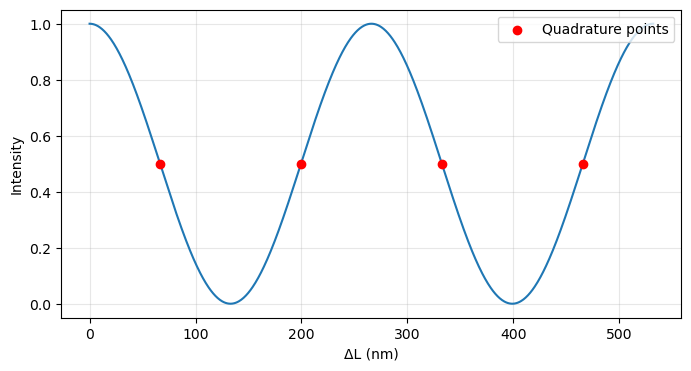

In [20]:
import numpy as np
import matplotlib.pyplot as plt

wavl = 532e-9
dL = np.linspace(0, wavl, 1000)
Ir = 0.5 * (1 + np.cos((4*np.pi/wavl)*dL))

dL_quad = wavl/8 + np.arange(0, 20) * wavl/4
dL_quad = dL_quad[dL_quad <= dL.max()]



fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dL*1e9, Ir)
ax.scatter(dL_quad*1e9,
            0.5 * (1 + np.cos((4*np.pi/wavl)*dL_quad)),
            color='red', zorder=3, label='Quadrature points')
ax.set_xlabel("ΔL (nm)")
ax.set_ylabel("Intensity")
ax.legend(loc = 1)
ax.grid(True, alpha=0.3)
